### Testing cubes/construct package

This is a notebook to perform a test to determine if the construct package can produce a reliable idf file

In [1]:
from cubes.construct import building
from cubes.construct import sample
from cubes.construct.extractor import Extractor
from cubes.construct import constants
from geomeppy import IDF
import numpy as np
import pandas as pd
import math

import os
from pathlib import Path

In [2]:
def sample_idf():
    geometry_data, systems_data = sample.sample_database(
        constants.filtered_geometry_data, constants.clean_system_data
    )
    building_config = Extractor(geometry_data, systems_data)
    build = building.Building(building_config)
    build.build()
    idf = build.get_idf()

    return geometry_data

def test_walls():
    geometry_data, systems_data = sample.sample_database(
        constants.filtered_geometry_data, constants.clean_system_data
    )
    building_config = Extractor(geometry_data, systems_data)
    walls = building_config.calc_wall_length()
    
    return walls, geometry_data

def test_idf():

    idf1 = sample_idf()
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf1.save()
    idf1.run(
        expandobjects=True,
        weather=(
            "/workspaces/CUBES/src/cubes/data/weather/cambridge_lat=52.25_lng=0.25_period=2021.epw"
        ),
        output_directory=output_directory_path,
    )

def get_minimal_idf():
    geometry_data, systems_data = sample.sample_database(
        constants.filtered_geometry_data, constants.clean_system_data
    )
    building_config = Extractor(geometry_data, systems_data)
    build = building.Building(building_config)
    idf = build.get_idf()
    return idf

def get_specific_archetype(building_code):
    geometry_data = constants.raw_geometry_data[constants.raw_geometry_data['REFERENCE BUILDING CODE'] == building_code]
    systems_data =constants.clean_system_data[constants.clean_system_data['Building typology'] == building_code]

    geometry_data = geometry_data.reset_index(drop = True)
    return geometry_data
    
def test_specific_archetype(building_code):
    geometry_data = constants.raw_geometry_data[constants.raw_geometry_data['REFERENCE BUILDING CODE'] == building_code]
    systems_data =constants.clean_system_data[constants.clean_system_data['Building typology'] == building_code]

    geometry_data = geometry_data.reset_index(drop = True)
    systems_data = systems_data.reset_index(drop = True)

    building_config = Extractor(geometry_data, systems_data)
    build = building.Building(building_config)
    build.build()
    idf = build.get_idf()

    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf.save()
    idf.run(
        expandobjects=True,
        weather=(
            "/workspaces/CUBES/src/cubes/data/weather/cambridge_lat=52.25_lng=0.25_period=2021.epw"
        ),
        output_directory=output_directory_path,
    )

    

Series([], dtype: object) NaturalGas


/usr/local/lib/python3.9/dist-packages/geomeppy/view_geometry.py:56: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limits["x"])
/usr/local/lib/python3.9/dist-packages/geomeppy/view_geometry.py:57: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(limits["y"])
/usr/local/lib/python3.9/dist-packages/geomeppy/view_geometry.py:58: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim(limits["z"])


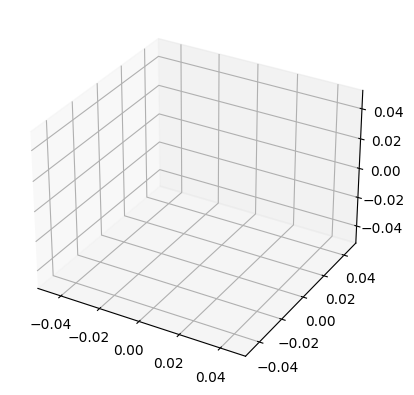

In [3]:
idf = get_minimal_idf()
idf.view_model()

In [4]:
test_specific_archetype("FR-SFH-2000-2005-00")

13    ZoneHVAC:LowTemperatureRadiant:Electric 
dtype: object Electricity

/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/CUBES/src/cubes/data/weather/cambridge_lat=52.25_lng=0.25_period=2021.epw --output-directory /workspaces/CUBES/exp/jack/construct-tests/input_case_1/output --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd --expandobjects /usr/local/EnergyPlus-9-5-0/ExampleFiles/Minimal_ca7e16.idf

ExpandObjects Started.
 Begin reading Energy+.idd file.
 Done reading Energy+.idd file.
ExpandObjects Finished with Error(s). Time:     0.043
EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2023.02.03 16:18
**FATAL:Preprocessor condition(s) cause termination.
EnergyPlus Run Time=00hr 00min  0.34sec


Program terminated: EnergyPlus Terminated--Error(s) Detected.


EnergyPlusRunError: 

Contents of EnergyPlus error file at /workspaces/CUBES/exp/jack/construct-tests/input_case_1/output/eplusout.err
Program Version,EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2023.02.03 16:18,
   ** Severe  ** Output:PreprocessorMessage="ExpandObjects" has the following Fatal conditions:
   **   ~~~   ** You must specify at least one HVACTemplate:System:VAV or
   **   ~~~   ** HVACTemplate:Zone:FanCoil or HVACTemplate:Zone:Unitary or
   **   ~~~   ** HVACTemplate:Zone:PTAC or HVACTemplate:Zone:PTHP or
   **   ~~~   ** HVACTemplate:Zone:WaterToAirHeatPump or
   **   ~~~   ** HVACTemplate:System:UnitaryHeatPump:AirToAir or
   **   ~~~   ** HVACTemplate:System:PackagedVAV or
   **   ~~~   ** HVACTemplate:System:DedicatedOutdoorAiror
   **   ~~~   ** HVACTemplate:System:ConstantVolume or HVACTemplate:System:DualDuctor
   **   ~~~   ** HVACTemplate:Zone:Baseboard or HVACTemplate:System:UnitarySystemor
   **   ~~~   ** HVACTemplate:System:VRF if a HVA
   **  Fatal  ** Pr

In [8]:
idf.idfobjects

{'VERSION': [
 Version,
     9.5;                      !- Version Identifier
 ],
 'SIMULATIONCONTROL': [
 SimulationControl,
     Yes,                      !- Do Zone Sizing Calculation
     No,                       !- Do System Sizing Calculation
     No,                       !- Do Plant Sizing Calculation
     Yes,                      !- Run Simulation for Sizing Periods
     No,                       !- Run Simulation for Weather File Run Periods
     No,                       !- Do HVAC Sizing Simulation for Sizing Periods
     1;                        !- Maximum Number of HVAC Sizing Simulation Passes
 ],
 'PERFORMANCEPRECISIONTRADEOFFS': [],
 'BUILDING': [
 Building,
     None,                     !- Name
     0,                        !- North Axis
     Suburbs,                  !- Terrain
     0.04,                     !- Loads Convergence Tolerance Value
     0.4,                      !- Temperature Convergence Tolerance Value
     FullInteriorAndExterior,    !- Solar Dist

In [ ]:
walls = {'Country': [], 'Code': [], 'wall_lengths': []}
for m in range(0,100):
    wall, gm = test_walls()
    walls['Country'].append(gm['REFERENCE BUILDING COUNTRY CODE'].values[0])
    walls['Code'].append(gm['REFERENCE BUILDING CODE'].values[0])
    walls['wall_lengths'].append(math.isnan(wall[0]))

df = pd.DataFrame.from_dict(walls)
df[df['wall_lengths'] == True]